# Gamma Scalping v2 — ETH Call Option

**Setup:**
- ETH Spot: $2,000
- Notional: $100,000 USD → 50 ETH
- Strike: 10% OTM → $2,200
- Expiry: 4 years
- Vol (σ): 65%
- Risk-free rate: 5% (adjust as needed)

Models Black-Scholes **delta** and **gamma** as a function of spot price and time to expiry.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm

# ── Parameters ──────────────────────────────────────────────────────────────
S0    = 2000.0   # current ETH spot
K     = 2200.0   # strike (10% OTM)
T     = 4.0      # time to expiry in years
sigma = 0.65     # implied vol
r     = 0.05     # risk-free rate
notional_usd = 100_000.0
qty_eth = notional_usd / S0   # 50 ETH

print(f"Quantity (ETH): {qty_eth:.2f}")
print(f"Strike:         ${K:,.0f}")
print(f"T:              {T}y | σ: {sigma:.0%} | r: {r:.0%}")

Quantity (ETH): 50.00
Strike:         $2,200
T:              4.0y | σ: 65% | r: 5%


In [3]:
# ── Black-Scholes helpers ────────────────────────────────────────────────────
def bs_d1(S, K, T, r, sigma):
    return (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))

def bs_delta_call(S, K, T, r, sigma):
    d1 = bs_d1(S, K, T, r, sigma)
    return norm.cdf(d1)

def bs_gamma(S, K, T, r, sigma):
    d1 = bs_d1(S, K, T, r, sigma)
    return norm.pdf(d1) / (S * sigma * np.sqrt(T))

def bs_price_call(S, K, T, r, sigma):
    d1 = bs_d1(S, K, T, r, sigma)
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

# ── At-the-money reference values ───────────────────────────────────────────
delta_now  = bs_delta_call(S0, K, T, r, sigma)
gamma_now  = bs_gamma(S0, K, T, r, sigma)
price_now  = bs_price_call(S0, K, T, r, sigma)

print(f"Option price (per ETH):  ${price_now:,.2f}")
print(f"Total option value:      ${price_now * qty_eth:,.2f}")
print(f"Delta (per ETH):         {delta_now:.4f}")
print(f"Portfolio delta (USD):   ${delta_now * qty_eth * S0:,.0f}")
print(f"Gamma (per ETH):         {gamma_now:.6f}")
print(f"Dollar gamma (per 1% Δspot): ${0.5 * gamma_now * S0**2 * 0.01**2 * qty_eth:,.2f}")

Option price (per ETH):  $1,022.46
Total option value:      $51,122.83
Delta (per ETH):         0.7675
Portfolio delta (USD):   $76,747
Gamma (per ETH):         0.000118
Dollar gamma (per 1% Δspot): $1.18


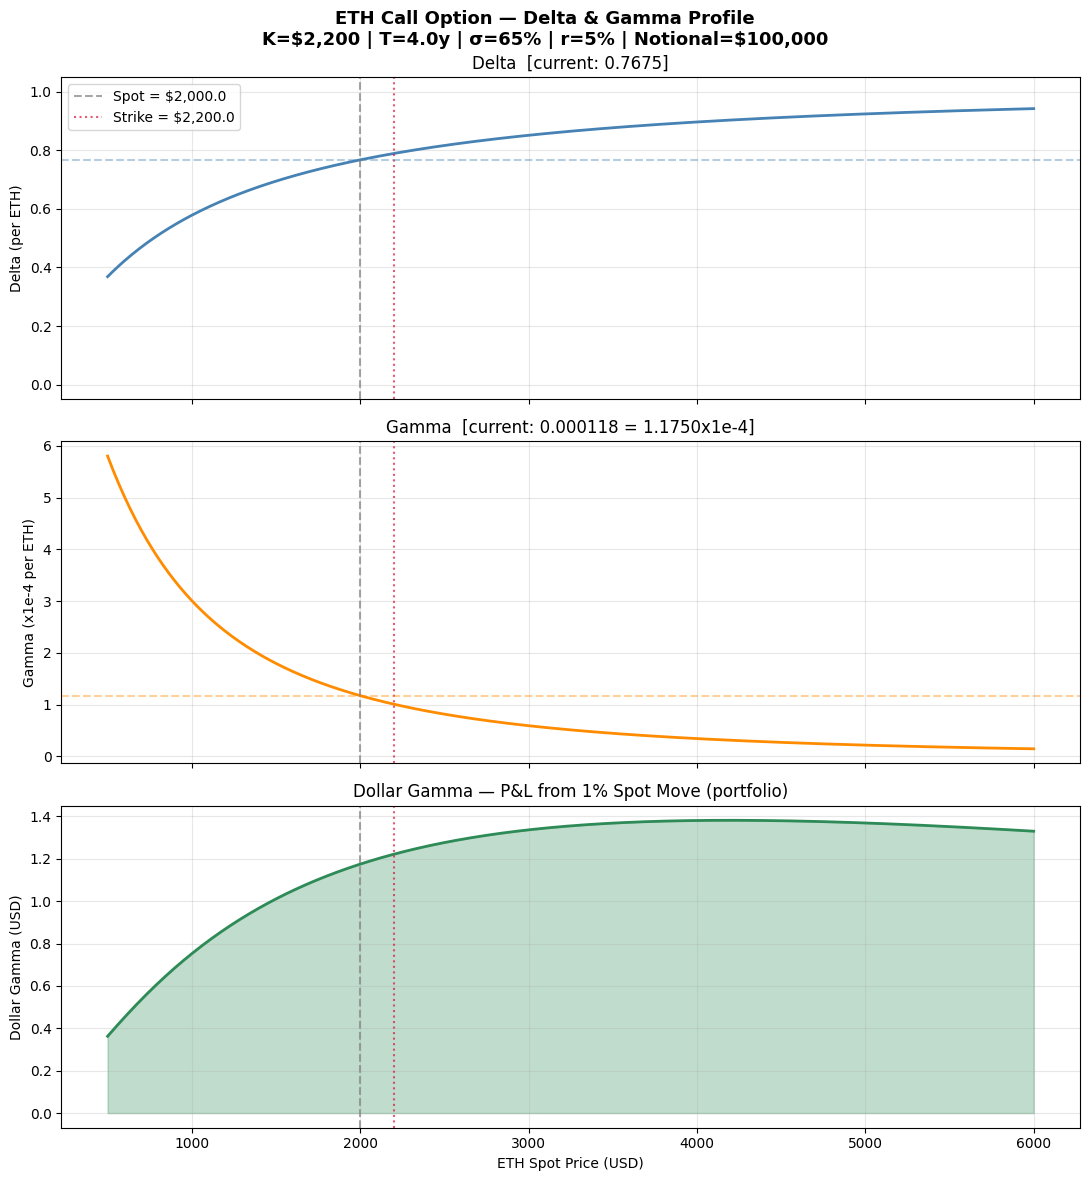

In [4]:
# ── Delta & Gamma vs Spot Price ──────────────────────────────────────────────
spots = np.linspace(500, 6000, 500)

deltas = bs_delta_call(spots, K, T, r, sigma)
gammas = bs_gamma(spots, K, T, r, sigma)

# Scale to portfolio
port_delta = deltas * qty_eth
port_gamma = gammas * qty_eth
dollar_gamma = 0.5 * gammas * spots**2 * 0.01**2 * qty_eth  # P&L per 1% spot move

fig, axes = plt.subplots(3, 1, figsize=(11, 12), sharex=True)
fig.suptitle(f'ETH Call Option — Delta & Gamma Profile\n'
             f'K=\${K:,.0f} | T={T}y | \u03c3={sigma:.0%} | r={r:.0%} | Notional=\${notional_usd:,.0f}',
             fontsize=13, fontweight='bold')

# Delta
axes[0].plot(spots, deltas, color='steelblue', lw=2)
axes[0].axvline(S0, color='gray', ls='--', alpha=0.7, label=f'Spot = \${S0:,}')
axes[0].axvline(K,  color='crimson', ls=':', alpha=0.7, label=f'Strike = \${K:,}')
axes[0].axhline(delta_now, color='steelblue', ls='--', alpha=0.4)
axes[0].set_ylabel('Delta (per ETH)')
axes[0].set_title(f'Delta  [current: {delta_now:.4f}]')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_ylim(-0.05, 1.05)

# Gamma
axes[1].plot(spots, gammas * 1e4, color='darkorange', lw=2)
axes[1].axvline(S0, color='gray', ls='--', alpha=0.7)
axes[1].axvline(K,  color='crimson', ls=':', alpha=0.7)
axes[1].axhline(gamma_now * 1e4, color='darkorange', ls='--', alpha=0.4)
axes[1].set_ylabel('Gamma (x1e-4 per ETH)')
axes[1].set_title(f'Gamma  [current: {gamma_now:.6f} = {gamma_now*1e4:.4f}x1e-4]')
axes[1].grid(alpha=0.3)

# Dollar Gamma (P&L per 1% move, full portfolio)
axes[2].fill_between(spots, dollar_gamma, alpha=0.3, color='seagreen')
axes[2].plot(spots, dollar_gamma, color='seagreen', lw=2)
axes[2].axvline(S0, color='gray', ls='--', alpha=0.7)
axes[2].axvline(K,  color='crimson', ls=':', alpha=0.7)
axes[2].set_ylabel('Dollar Gamma (USD)')
axes[2].set_xlabel('ETH Spot Price (USD)')
axes[2].set_title('Dollar Gamma — P&L from 1% Spot Move (portfolio)')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('gamma_scalp_v2_spot.png', dpi=150, bbox_inches='tight')
plt.show()


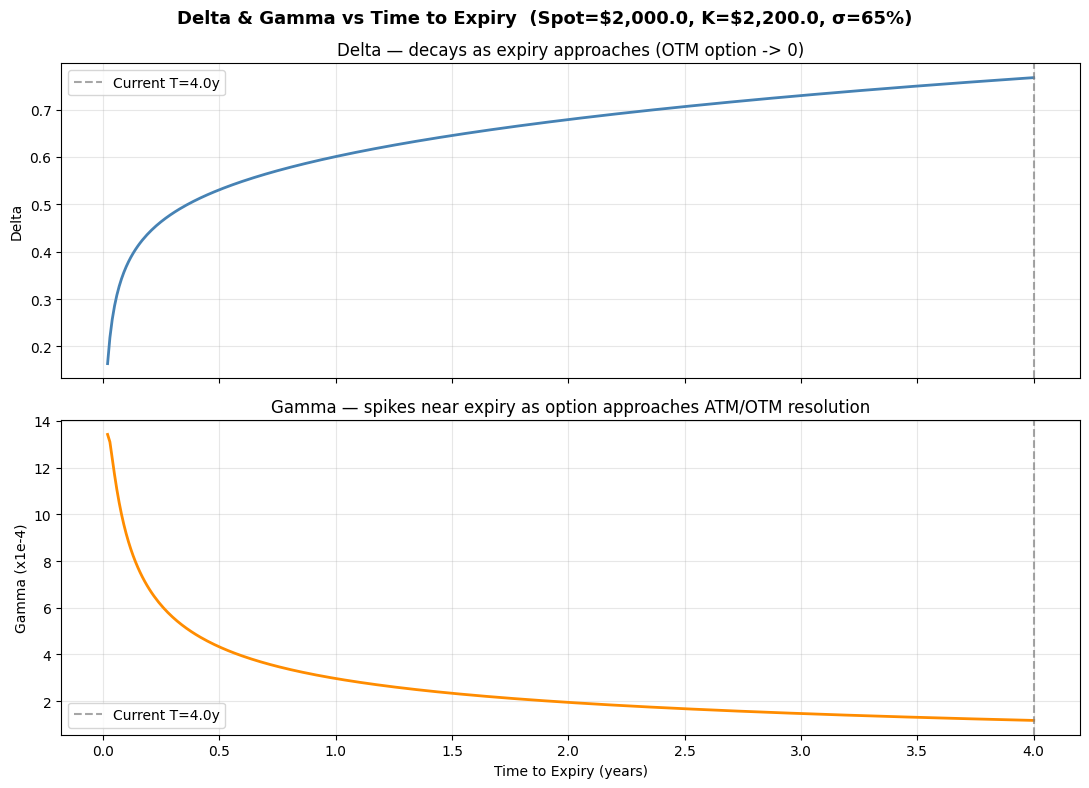

In [5]:
# ── Delta & Gamma vs Time to Expiry (at current spot) ───────────────────────
times = np.linspace(0.02, 4.0, 400)   # avoid T=0 singularity

deltas_t = bs_delta_call(S0, K, times, r, sigma)
gammas_t = bs_gamma(S0, K, times, r, sigma)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
fig.suptitle(f'Delta & Gamma vs Time to Expiry  (Spot=\${S0:,}, K=\${K:,}, \u03c3={sigma:.0%})',
             fontsize=13, fontweight='bold')

ax1.plot(times, deltas_t, color='steelblue', lw=2)
ax1.axvline(T, color='gray', ls='--', alpha=0.7, label=f'Current T={T}y')
ax1.set_ylabel('Delta')
ax1.set_title('Delta — decays as expiry approaches (OTM option -> 0)')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(times, gammas_t * 1e4, color='darkorange', lw=2)
ax2.axvline(T, color='gray', ls='--', alpha=0.7, label=f'Current T={T}y')
ax2.set_ylabel('Gamma (x1e-4)')
ax2.set_xlabel('Time to Expiry (years)')
ax2.set_title('Gamma — spikes near expiry as option approaches ATM/OTM resolution')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('gamma_scalp_v2_time.png', dpi=150, bbox_inches='tight')
plt.show()


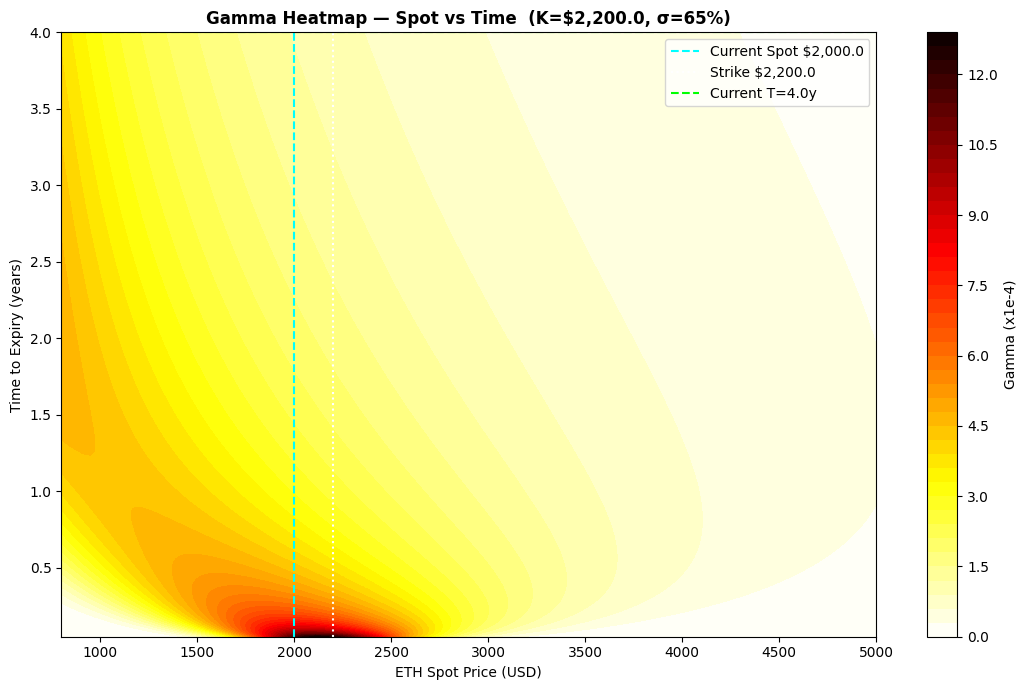

In [6]:
# ── Gamma Heatmap: Spot × Time ───────────────────────────────────────────────
spots_2d = np.linspace(800, 5000, 200)
times_2d = np.linspace(0.05, 4.0, 200)
SS, TT = np.meshgrid(spots_2d, times_2d)

GG = bs_gamma(SS, K, TT, r, sigma) * 1e4

fig, ax = plt.subplots(figsize=(11, 7))
cf = ax.contourf(SS, TT, GG, levels=50, cmap='hot_r')
fig.colorbar(cf, ax=ax, label='Gamma (x1e-4)')
ax.set_xlabel('ETH Spot Price (USD)')
ax.set_ylabel('Time to Expiry (years)')
ax.set_title(f'Gamma Heatmap — Spot vs Time  (K=\${K:,}, \u03c3={sigma:.0%})', fontweight='bold')
ax.axvline(S0, color='cyan', lw=1.5, ls='--', label=f'Current Spot \${S0:,}')
ax.axvline(K,  color='white', lw=1.5, ls=':', label=f'Strike \${K:,}')
ax.axhline(T,  color='lime', lw=1.5, ls='--', label=f'Current T={T}y')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('gamma_scalp_v2_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


In [7]:
# ── Summary Table ────────────────────────────────────────────────────────────
print("=" * 60)
print("POSITION SUMMARY")
print("=" * 60)
scenario_spots = [1000, 1500, 2000, 2200, 2500, 3000, 4000]
print(f"{'Spot':>8} {'Delta':>8} {'Gamma(e-4)':>12} {'DollarGamma':>14} {'OptPrice':>10}")
print("-" * 60)
for s in scenario_spots:
    d  = bs_delta_call(s, K, T, r, sigma)
    g  = bs_gamma(s, K, T, r, sigma)
    dg = 0.5 * g * s**2 * 0.01**2 * qty_eth
    p  = bs_price_call(s, K, T, r, sigma)
    marker = " ◄ current" if s == S0 else ""
    print(f"${s:>7,} {d:>8.4f} {g*1e4:>12.4f} ${dg:>13,.2f} ${p:>9,.2f}{marker}")

POSITION SUMMARY
    Spot    Delta   Gamma(e-4)    DollarGamma   OptPrice
------------------------------------------------------------
$  1,000   0.5782       3.0096 $         0.75 $   334.90
$  1,500   0.6947       1.7971 $         1.01 $   655.63
$  2,000   0.7675       1.1750 $         1.18 $ 1,022.46 ◄ current
$  2,200   0.7893       1.0098 $         1.22 $ 1,178.18
$  2,500   0.8165       0.8171 $         1.28 $ 1,419.19
$  3,000   0.8514       0.5941 $         1.34 $ 1,836.64
$  4,000   0.8968       0.3452 $         1.38 $ 2,712.80


# Roll Analysis — When to Exercise & Rebond

**Core question:** At what spot price (given time remaining) does it make more sense to exercise the current ITM American call and redeploy into a fresh 4-year call struck 10% OTM at the new spot?

**Framework:**
- **Time value surrendered** = what you give up by exercising early (the "cost" of rolling)
- **Gamma efficiency** = Dollar Gamma per dollar of option premium — measures convexity per dollar deployed
- **Roll signal** = when the new option's gamma efficiency sufficiently exceeds the current option's gamma efficiency to justify surrendering remaining time value

In [8]:
# ── Roll Analysis: Core Metrics vs Spot ─────────────────────────────────────
# For each spot S, compare holding the current option vs rolling into a fresh one.
#
# Current option: K_old=2200, T_rem (parameterised below)
# New option:     K_new=1.1*S (always 10% OTM), T_new=4 years
#
# Key metrics:
#   intrinsic_old      = max(S - K_old, 0)
#   TV_old             = C_old - intrinsic_old          (time value surrendered on exercise)
#   capital_to_roll    = C_new - intrinsic_old          (net cash needed; negative = roll generates cash)
#   gamma_eff          = dollar_gamma / option_price    (convexity per dollar of premium)
#   gamma_eff_ratio    = gamma_eff_new / gamma_eff_old  (>1 favours rolling)

T_NEW   = 4.0          # fresh option is always a 4-year
OTM_PCT = 0.10         # new strike is always 10% OTM

def dollar_gamma_per_eth(S, K, T, r, sigma):
    """Dollar P&L from a 1% spot move, per ETH of option."""
    g = bs_gamma(S, K, T, r, sigma)
    return 0.5 * g * S**2 * 0.01**2

def gamma_efficiency(S, K, T, r, sigma):
    """Dollar gamma per dollar of option premium (per ETH, dimensionless ratio)."""
    price = bs_price_call(S, K, T, r, sigma)
    dg    = dollar_gamma_per_eth(S, K, T, r, sigma)
    return np.where(price > 1e-8, dg / np.maximum(price, 1e-8), np.nan)

# Sweep spots from current (S0) up to 3× strike
roll_spots = np.linspace(S0, 3 * K, 500)

def roll_metrics(spots, T_rem):
    """Compute roll metrics for a given time-remaining on the current option."""
    K_old = K  # original strike

    C_old       = bs_price_call(spots, K_old, T_rem, r, sigma)
    intrinsic   = np.maximum(spots - K_old, 0)
    TV_old      = C_old - intrinsic                         # time value surrendered

    K_new       = (1 + OTM_PCT) * spots                    # fresh strike, always 10% OTM
    C_new       = bs_price_call(spots, K_new, T_NEW, r, sigma)
    cap_to_roll = C_new - intrinsic                         # net capital required to roll

    ge_old      = gamma_efficiency(spots, K_old, T_rem, r, sigma)
    ge_new      = gamma_efficiency(spots, K_new, T_NEW, r, sigma)
    ge_ratio    = ge_new / ge_old                           # >1 = new option more efficient

    delta_old   = bs_delta_call(spots, K_old, T_rem, r, sigma)

    return {
        'C_old':       C_old,
        'intrinsic':   intrinsic,
        'TV_old':      TV_old,
        'C_new':       C_new,
        'cap_to_roll': cap_to_roll,
        'ge_old':      ge_old,
        'ge_new':      ge_new,
        'ge_ratio':    ge_ratio,
        'delta_old':   delta_old,
    }

m = roll_metrics(roll_spots, T_rem=T)   # T=4 (full life remaining)

print("Roll Metrics at T_rem=4y")
print(f"{'Spot':>8} {'C_old':>9} {'Intrinsic':>10} {'TV_old':>8} "
      f"{'C_new':>9} {'CapToRoll':>11} {'GE_ratio':>10} {'Delta':>7}")
print("-" * 80)
for s in [2000, 2500, 3000, 3500, 4000, 5000, 6000]:
    idx = min(np.searchsorted(roll_spots, s), len(roll_spots) - 1)
    print(f"${s:>7,} ${m['C_old'][idx]:>8,.2f} ${m['intrinsic'][idx]:>9,.2f} "
          f"${m['TV_old'][idx]:>7,.2f} ${m['C_new'][idx]:>8,.2f} "
          f"${m['cap_to_roll'][idx]:>10,.2f} {m['ge_ratio'][idx]:>10.3f}x "
          f"{m['delta_old'][idx]:>7.4f}")

Roll Metrics at T_rem=4y
    Spot     C_old  Intrinsic   TV_old     C_new   CapToRoll   GE_ratio   Delta
--------------------------------------------------------------------------------
$  2,000 $1,022.46 $     0.00 $1,022.46 $1,022.46 $  1,022.46      1.000x  0.7675
$  2,500 $1,424.92 $   307.01 $1,117.91 $1,281.66 $    974.64      1.282x  0.8171
$  3,000 $1,840.73 $   804.81 $1,035.92 $1,536.14 $    731.33      1.582x  0.8517
$  3,500 $2,271.37 $ 1,302.61 $ 968.76 $1,790.63 $    488.03      1.907x  0.8773
$  4,000 $2,713.16 $ 1,800.40 $ 912.76 $2,045.12 $    244.72      2.258x  0.8968
$  5,000 $3,629.28 $ 2,805.21 $ 824.07 $2,558.81 $   -246.41      3.046x  0.9245
$  6,000 $4,559.24 $ 3,800.80 $ 758.43 $3,067.78 $   -733.02      3.939x  0.9425


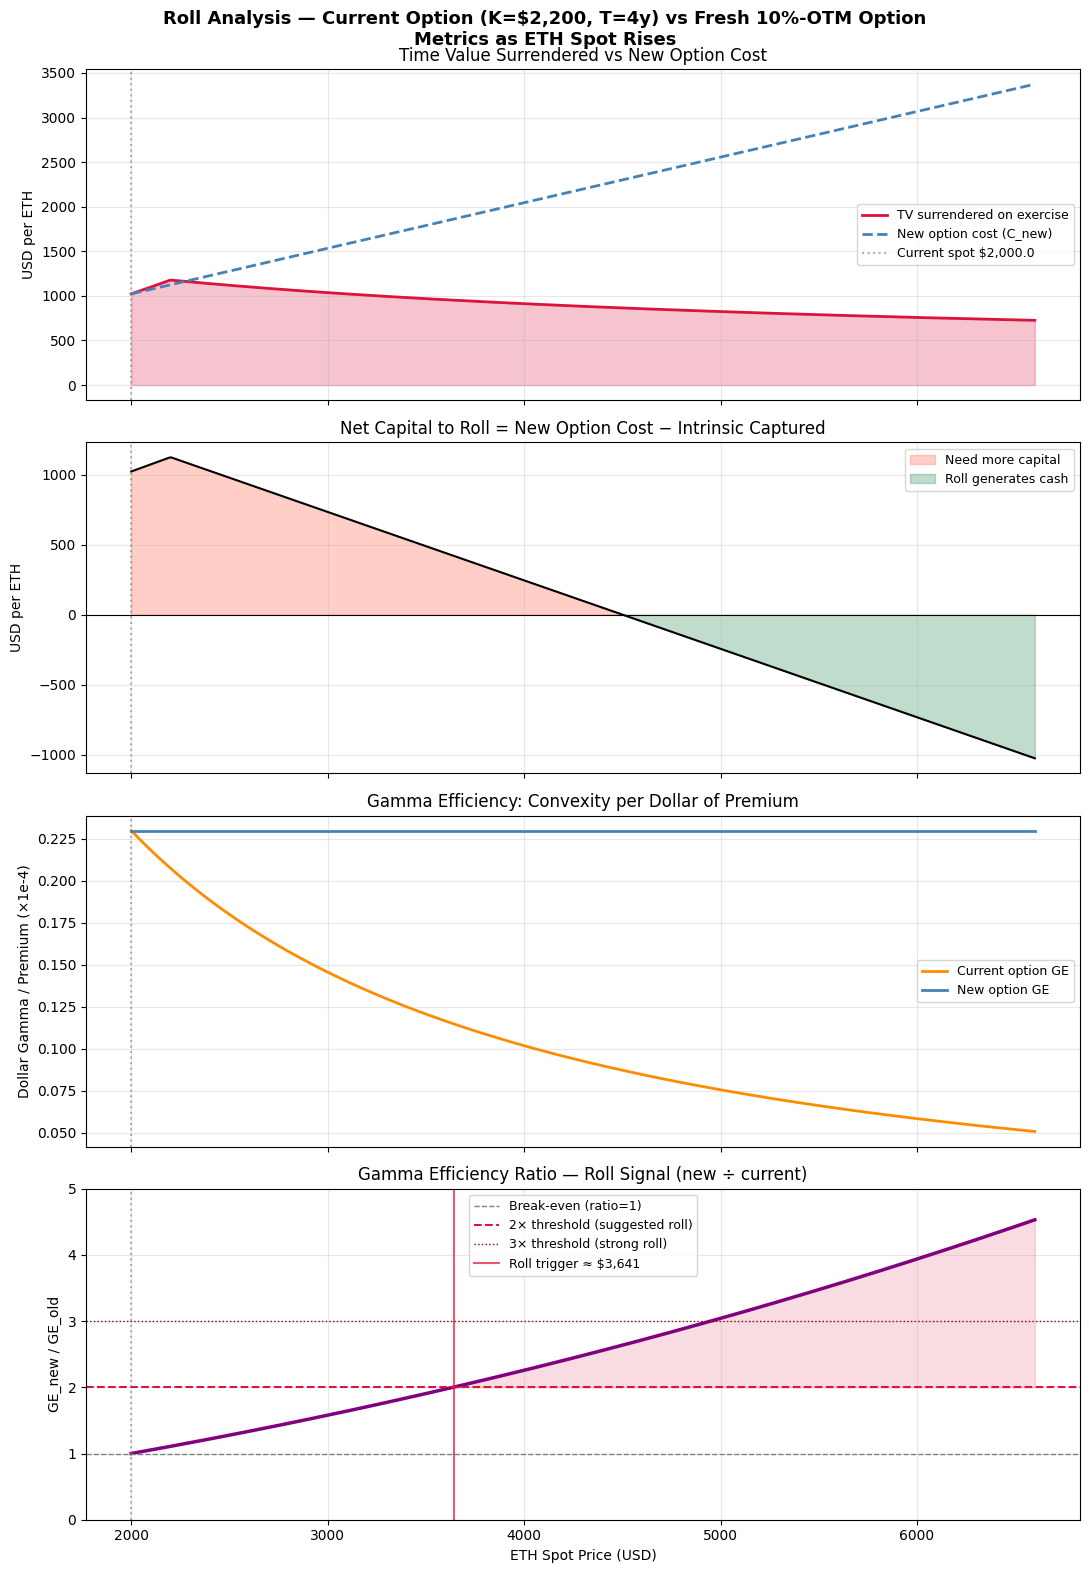

In [9]:
# ── Plot: Roll Metrics vs Spot (T_rem = 4y) ─────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(11, 16), sharex=True)
fig.suptitle('Roll Analysis — Current Option (K=$2,200, T=4y) vs Fresh 10%-OTM Option\n'
             'Metrics as ETH Spot Rises', fontsize=13, fontweight='bold')

# 1. Time value surrendered on exercise
axes[0].fill_between(roll_spots, m['TV_old'], alpha=0.25, color='crimson')
axes[0].plot(roll_spots, m['TV_old'], color='crimson', lw=2, label='TV surrendered on exercise')
axes[0].plot(roll_spots, m['C_new'], color='steelblue', lw=2, ls='--', label='New option cost (C_new)')
axes[0].axvline(S0, color='gray', ls=':', alpha=0.6, label=f'Current spot ${S0:,}')
axes[0].set_ylabel('USD per ETH')
axes[0].set_title('Time Value Surrendered vs New Option Cost')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# 2. Net capital to roll (C_new − intrinsic captured)
pos_mask = m['cap_to_roll'] >= 0
neg_mask = ~pos_mask
axes[1].fill_between(roll_spots, m['cap_to_roll'], where=pos_mask,
                     alpha=0.3, color='tomato', label='Need more capital')
axes[1].fill_between(roll_spots, m['cap_to_roll'], where=neg_mask,
                     alpha=0.3, color='seagreen', label='Roll generates cash')
axes[1].plot(roll_spots, m['cap_to_roll'], color='black', lw=1.5)
axes[1].axhline(0, color='black', lw=0.8)
axes[1].axvline(S0, color='gray', ls=':', alpha=0.6)
axes[1].set_ylabel('USD per ETH')
axes[1].set_title('Net Capital to Roll = New Option Cost − Intrinsic Captured')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

# 3. Gamma efficiency: old vs new
axes[2].plot(roll_spots, m['ge_old'] * 1e4, color='darkorange', lw=2, label='Current option GE')
axes[2].plot(roll_spots, m['ge_new'] * 1e4, color='steelblue', lw=2, label='New option GE')
axes[2].axvline(S0, color='gray', ls=':', alpha=0.6)
axes[2].set_ylabel('Dollar Gamma / Premium (×1e-4)')
axes[2].set_title('Gamma Efficiency: Convexity per Dollar of Premium')
axes[2].legend(fontsize=9)
axes[2].grid(alpha=0.3)

# 4. Gamma efficiency ratio (the key signal)
axes[3].plot(roll_spots, m['ge_ratio'], color='purple', lw=2.5)
axes[3].axhline(1.0, color='gray', ls='--', lw=1, label='Break-even (ratio=1)')
axes[3].axhline(2.0, color='crimson', ls='--', lw=1.5, label='2× threshold (suggested roll)')
axes[3].axhline(3.0, color='darkred', ls=':', lw=1, label='3× threshold (strong roll)')
axes[3].fill_between(roll_spots, 2.0, m['ge_ratio'],
                     where=(m['ge_ratio'] >= 2.0), alpha=0.15, color='crimson')
axes[3].axvline(S0, color='gray', ls=':', alpha=0.6)
# Mark where ratio first crosses 2×
cross_idx = np.argmax(m['ge_ratio'] >= 2.0)
if m['ge_ratio'][cross_idx] >= 2.0:
    axes[3].axvline(roll_spots[cross_idx], color='crimson', ls='-', lw=1.5, alpha=0.7,
                    label=f'Roll trigger ≈ ${roll_spots[cross_idx]:,.0f}')
axes[3].set_ylabel('GE_new / GE_old')
axes[3].set_xlabel('ETH Spot Price (USD)')
axes[3].set_title('Gamma Efficiency Ratio — Roll Signal (new ÷ current)')
axes[3].legend(fontsize=9)
axes[3].set_ylim(0, 5)
axes[3].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('gamma_scalp_v2_roll_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

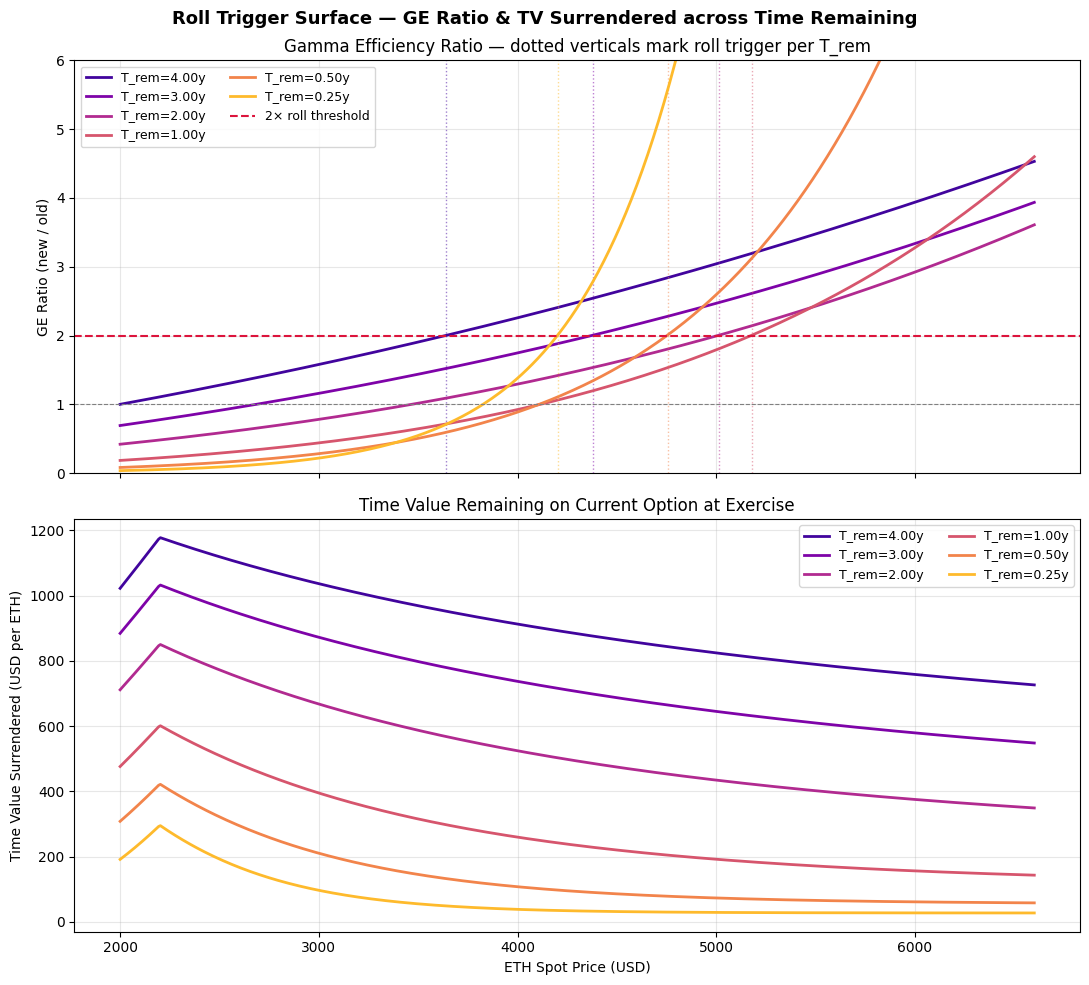


ROLL TRIGGER TABLE  (GE Ratio ≥ 2× threshold)
 T_rem   Trigger Spot    % ITM    Delta   TV Surrendered
---------------------------------------------------------------------------
  4.00y  $       3,641     65.5%    0.8832  $        952.21
  3.00y  $       4,378     99.0%    0.9045  $        698.51
  2.00y  $       5,014    127.9%    0.9285  $        433.52
  1.00y  $       5,180    135.5%    0.9572  $        183.82
  0.50y  $       4,756    116.2%    0.9751  $         78.66
  0.25y  $       4,203     91.1%    0.9858  $         34.93


In [10]:
# ── Roll Trigger Surface: GE Ratio across T_remaining ────────────────────────
# As time decays on the current option, the roll trigger spot changes.
# At lower T_rem, there's less time value left, so the bar to roll is lower
# (cheaper to surrender TV, so the optimal roll point shifts leftward / triggers earlier).

T_rems = [4.0, 3.0, 2.0, 1.0, 0.5, 0.25]
colors = plt.cm.plasma(np.linspace(0.1, 0.85, len(T_rems)))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 10), sharex=True)
fig.suptitle('Roll Trigger Surface — GE Ratio & TV Surrendered across Time Remaining',
             fontsize=13, fontweight='bold')

roll_table = []

for T_rem, col in zip(T_rems, colors):
    m_t = roll_metrics(roll_spots, T_rem)

    ax1.plot(roll_spots, m_t['ge_ratio'], color=col, lw=2, label=f'T_rem={T_rem:.2f}y')
    ax2.plot(roll_spots, m_t['TV_old'],   color=col, lw=2, label=f'T_rem={T_rem:.2f}y')

    # Find roll trigger at 2× GE ratio threshold
    cross = np.argmax(m_t['ge_ratio'] >= 2.0)
    if m_t['ge_ratio'][cross] >= 2.0:
        trig_spot  = roll_spots[cross]
        trig_delta = m_t['delta_old'][cross]
        trig_TV    = m_t['TV_old'][cross]
        trig_pct   = (trig_spot / K - 1) * 100
        roll_table.append((T_rem, trig_spot, trig_pct, trig_delta, trig_TV))
        ax1.axvline(trig_spot, color=col, ls=':', lw=1, alpha=0.5)

ax1.axhline(2.0, color='crimson', ls='--', lw=1.5, label='2× roll threshold')
ax1.axhline(1.0, color='gray',    ls='--', lw=0.8)
ax1.set_ylabel('GE Ratio (new / old)')
ax1.set_title('Gamma Efficiency Ratio — dotted verticals mark roll trigger per T_rem')
ax1.legend(fontsize=9, ncol=2)
ax1.set_ylim(0, 6)
ax1.grid(alpha=0.3)

ax2.set_ylabel('Time Value Surrendered (USD per ETH)')
ax2.set_xlabel('ETH Spot Price (USD)')
ax2.set_title('Time Value Remaining on Current Option at Exercise')
ax2.legend(fontsize=9, ncol=2)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('gamma_scalp_v2_roll_surface.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Roll Trigger Table ────────────────────────────────────────────────────────
print("\n" + "=" * 75)
print("ROLL TRIGGER TABLE  (GE Ratio ≥ 2× threshold)")
print("=" * 75)
print(f"{'T_rem':>6} {'Trigger Spot':>14} {'% ITM':>8} {'Delta':>8} "
      f"{'TV Surrendered':>16}")
print("-" * 75)
for row in roll_table:
    T_rem, spot, pct, delta, tv = row
    print(f"{T_rem:>6.2f}y  ${spot:>12,.0f}  {pct:>7.1f}%  {delta:>8.4f}  ${tv:>14,.2f}")

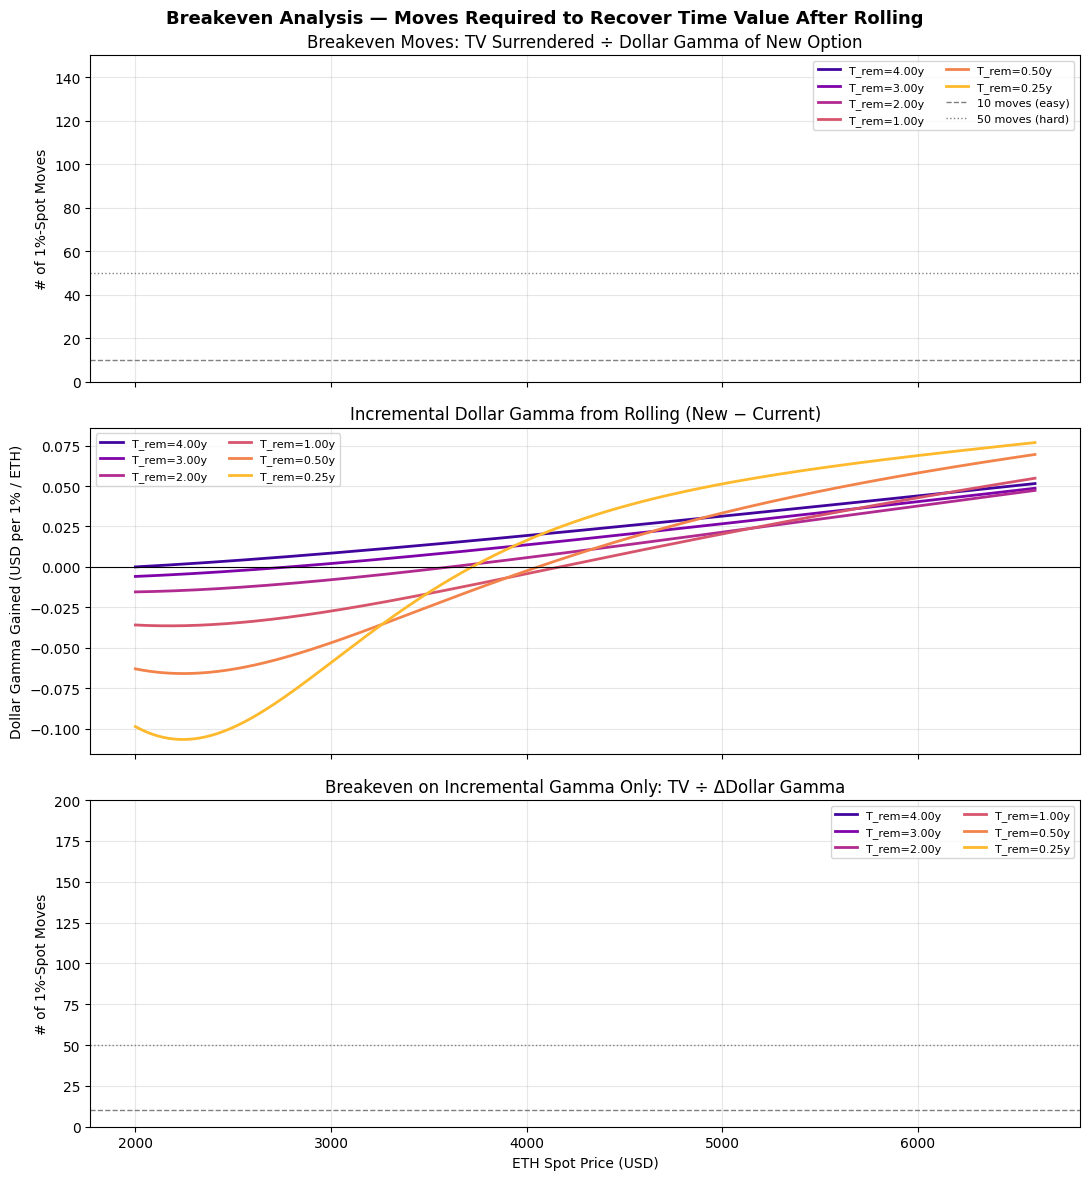

In [11]:
# ── Breakeven Analysis: How far must ETH move to recover TV surrendered? ──────
# After rolling, the new option has a higher dollar gamma than the old deep-ITM option.
# The "breakeven move" = TV_surrendered / dollar_gamma_new (per ETH).
# This is how many 1%-of-spot moves the new option needs to earn back the time value given up.
# Lower breakeven = rolling is cheaper / more justified.
#
# Note: this is a first-order approximation (uses current dollar gamma, not path integral).
# It understates the breakeven for small gammas and overstates for large, but is directionally clean.

fig, axes = plt.subplots(3, 1, figsize=(11, 12), sharex=True)
fig.suptitle('Breakeven Analysis — Moves Required to Recover Time Value After Rolling',
             fontsize=13, fontweight='bold')

for T_rem, col in zip(T_rems, colors):
    m_t  = roll_metrics(roll_spots, T_rem)
    K_new = (1 + OTM_PCT) * roll_spots
    dg_new = dollar_gamma_per_eth(roll_spots, K_new, T_NEW, r, sigma)
    dg_old = dollar_gamma_per_eth(roll_spots, K,    T_rem, r, sigma)

    # Number of 1% moves to earn back TV
    breakeven_moves = m_t['TV_old'] / dg_new

    # Equivalent continuous spot move to break even (rough geometric approx)
    breakeven_pct = breakeven_moves * 1.0    # each unit = 1% spot move

    # Delta gamma gained by rolling (per ETH)
    delta_dg = (dg_new - dg_old)

    axes[0].plot(roll_spots, breakeven_moves, color=col, lw=2, label=f'T_rem={T_rem:.2f}y')
    axes[1].plot(roll_spots, dg_new - dg_old, color=col, lw=2, label=f'T_rem={T_rem:.2f}y')
    axes[2].plot(roll_spots, m_t['TV_old'] / np.maximum(dg_new - dg_old, 1e-8),
                 color=col, lw=2, label=f'T_rem={T_rem:.2f}y')

axes[0].axhline(10, color='gray', ls='--', lw=1, label='10 moves (easy)')
axes[0].axhline(50, color='gray', ls=':',  lw=1, label='50 moves (hard)')
axes[0].set_ylabel('# of 1%-Spot Moves')
axes[0].set_title('Breakeven Moves: TV Surrendered ÷ Dollar Gamma of New Option')
axes[0].legend(fontsize=8, ncol=2)
axes[0].set_ylim(0, 150)
axes[0].grid(alpha=0.3)

axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_ylabel('Dollar Gamma Gained (USD per 1% / ETH)')
axes[1].set_title('Incremental Dollar Gamma from Rolling (New − Current)')
axes[1].legend(fontsize=8, ncol=2)

axes[1].grid(alpha=0.3)

axes[2].axhline(10, color='gray', ls='--', lw=1)
axes[2].axhline(50, color='gray', ls=':',  lw=1)
axes[2].set_ylabel('# of 1%-Spot Moves')
axes[2].set_xlabel('ETH Spot Price (USD)')
axes[2].set_title('Breakeven on Incremental Gamma Only: TV ÷ ΔDollar Gamma')
axes[2].legend(fontsize=8, ncol=2)
axes[2].set_ylim(0, 200)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('gamma_scalp_v2_breakeven.png', dpi=150, bbox_inches='tight')
plt.show()

## Roll Framework Summary

### Three complementary signals — use all three together:

| Signal | Definition | Roll when... |
|--------|------------|--------------|
| **GE Ratio** | Dollar Gamma / Premium of new ÷ old | ≥ 2× |
| **Delta** | Delta of current option | ≥ 0.90 |
| **Breakeven moves** | TV surrendered ÷ dollar gamma of new option | ≤ 20–30 moves |

### Key properties of the roll trigger:
- **Time decay lowers the bar**: as T_rem shrinks, less TV is left to surrender, so the roll trigger spot moves *down* — you should roll sooner (in spot terms) as the option ages
- **Rolling generates cash at high spots**: once intrinsic >> C_new, exercising and rebonding actually frees up capital to scale the position
- **The new option always starts with higher GE**: a fresh 10%-OTM call is in the maximum-gamma zone; the current deep-ITM call has bled its convexity into delta

### What's NOT modelled here (extensions):
- **Volatility surface**: roll should also consider whether IV on new option is cheap or expensive vs. historical
- **Path dependence**: a Monte Carlo sim would capture the actual P&L distribution of roll-then-hold vs. hold-through
- **Transaction costs**: each roll has bid/ask friction; matters more at shorter T_rem when TV surrendered is small
- **Tax / realization events**: exercising crystallises a gain; relevant for real capital